In [1]:
!pip install torch numpy matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os

ALPHA       = 1.0
T_MAX       = 0.01
SIGMA_BANDS = [1, 3, 5]
M_FREQ      = 32
MLP_HIDDEN  = [256] * 6
MODEL_PATH  = '../../results/pinn_parametric.pt'
OUT_DIR     = '../../results/ood/failure'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
print(f'Device: {DEVICE}')

Device: cpu


In [3]:
def T_exact(x, y, t, Lx, Ly, alpha=ALPHA):
    lam1 = np.pi**2 * alpha * (1/Lx**2 + 1/Ly**2)
    lam2 = 25 * lam1
    low  = np.sin(np.pi*x/Lx) * np.sin(np.pi*y/Ly) * np.exp(-lam1*t)
    high = 0.3 * np.sin(5*np.pi*x/Lx) * np.sin(5*np.pi*y/Ly) * np.exp(-lam2*t)
    return low + high

In [4]:
class ParametricFourierNet(nn.Module):
    def __init__(self, sigma_bands, m_freq, mlp_hidden, t_max):
        super().__init__()
        self.sigma_bands = sigma_bands; self.t_max = t_max
        n_fourier = len(sigma_bands) * 2 * m_freq
        for i, sigma in enumerate(sigma_bands):
            B = torch.randn(3, m_freq) * sigma
            self.register_parameter(f'B_{i}', nn.Parameter(B, requires_grad=False))
        sizes = [n_fourier + 2] + mlp_hidden + [1]
        layers = []
        for in_sz, out_sz in zip(sizes[:-2], sizes[1:-1]):
            layers += [nn.Linear(in_sz, out_sz), nn.Tanh()]
        layers.append(nn.Linear(sizes[-2], sizes[-1]))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        lx = x[:,3:4]; ly = x[:,4:5]
        xi_n  = 2.0*x[:,0:1]/lx - 1.0
        eta_n = 2.0*x[:,1:2]/ly - 1.0
        t_n   = 2.0*x[:,2:3]/self.t_max - 1.0
        lx_n  = (lx - 1.25)/0.75; ly_n = (ly - 1.25)/0.75
        coords = torch.cat([xi_n, eta_n, t_n], dim=1)
        features = []
        for i in range(len(self.sigma_bands)):
            B = getattr(self, f'B_{i}'); proj = coords @ B
            features += [torch.sin(proj), torch.cos(proj)]
        return self.mlp(torch.cat(features + [lx_n, ly_n], dim=-1))

In [5]:
model = ParametricFourierNet(SIGMA_BANDS, M_FREQ, MLP_HIDDEN, T_MAX).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f'Model loaded. Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Model loaded. Trainable params: 379,137


In [6]:
def eval_l2(Lx, Ly, t_val, alpha_true=ALPHA, grid_n=80):
    x_lin = np.linspace(0, Lx, grid_n); y_lin = np.linspace(0, Ly, grid_n)
    X, Y  = np.meshgrid(x_lin, y_lin)
    pts   = torch.tensor(np.column_stack([X.ravel(), Y.ravel(),
                np.full(X.size, t_val), np.full(X.size, Lx), np.full(X.size, Ly)]),
                dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        T_pred = model(pts).cpu().numpy().reshape(grid_n, grid_n)
    T_true = T_exact(X, Y, t_val, Lx, Ly, alpha=alpha_true)
    denom  = np.linalg.norm(T_true)
    l2     = np.linalg.norm(T_pred - T_true) / denom if denom > 1e-12 else float('nan')
    return l2, T_pred, T_true

l2_ref, _, _ = eval_l2(1.0, 1.0, 0.001)
print(f'In-dist sanity check  Lx=Ly=1 t=0.001: L2 = {l2_ref:.2e}')

In-dist sanity check  Lx=Ly=1 t=0.001: L2 = 1.58e-02


## Case 1 — Geometry Extrapolation
Training range: `Lx, Ly ∈ [0.5, 2.0]`. Below we sweep Lx from 0.1 to 4.0 with Ly fixed,
then show field comparisons for geometries from in-distribution to far outside.

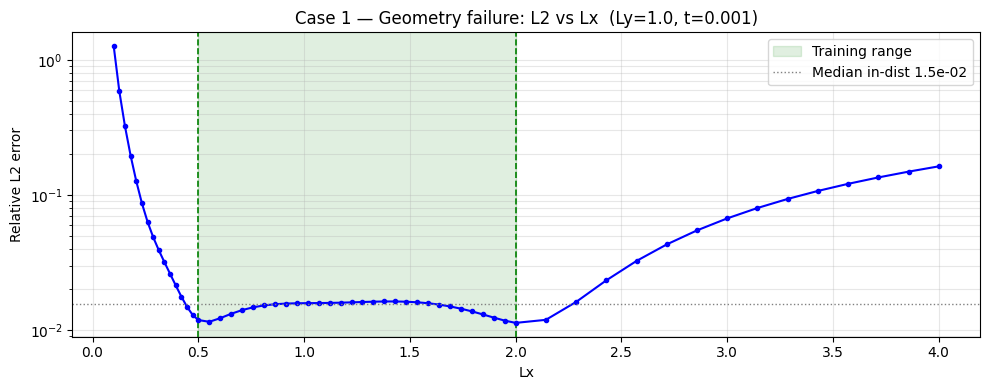

Saved case1_geometry_sweep.png


In [7]:
lx_vals = np.unique(np.concatenate([
    np.linspace(0.1, 0.5, 15, endpoint=False),
    np.linspace(0.5, 2.0, 30),
    np.linspace(2.0, 4.0, 15)
]))
Ly_fixed = 1.0

errs = [eval_l2(Lx, Ly_fixed, 0.001)[0] for Lx in lx_vals]
in_mask = (lx_vals >= 0.5) & (lx_vals <= 2.0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axvspan(0.5, 2.0, alpha=0.12, color='green', label='Training range')
ax.axvline(0.5, color='green', ls='--', lw=1.2)
ax.axvline(2.0, color='green', ls='--', lw=1.2)
ax.semilogy(lx_vals, errs, 'b-o', ms=3, lw=1.5)
ax.axhline(np.median(np.array(errs)[in_mask]), color='grey', ls=':', lw=1,
           label=f'Median in-dist {np.median(np.array(errs)[in_mask]):.1e}')
ax.set_xlabel('Lx'); ax.set_ylabel('Relative L2 error')
ax.set_title(f'Case 1 — Geometry failure: L2 vs Lx  (Ly={Ly_fixed}, t=0.001)')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/case1_geometry_sweep.png', dpi=150); plt.show()
print('Saved case1_geometry_sweep.png')

                    Case |   lx_n |        L2
       In-dist   1.0x1.0 |  -0.33 |  1.58e-02
       Near-OOD  0.3x1.0 |  -1.27 |  4.34e-02
       Near-OOD  1.0x2.5 |  -0.33 |  2.55e-02
     Far-OOD   0.15x0.15 |  -1.47 |  9.30e-01
       Far-OOD   3.5x3.5 |   3.00 |  3.20e-01


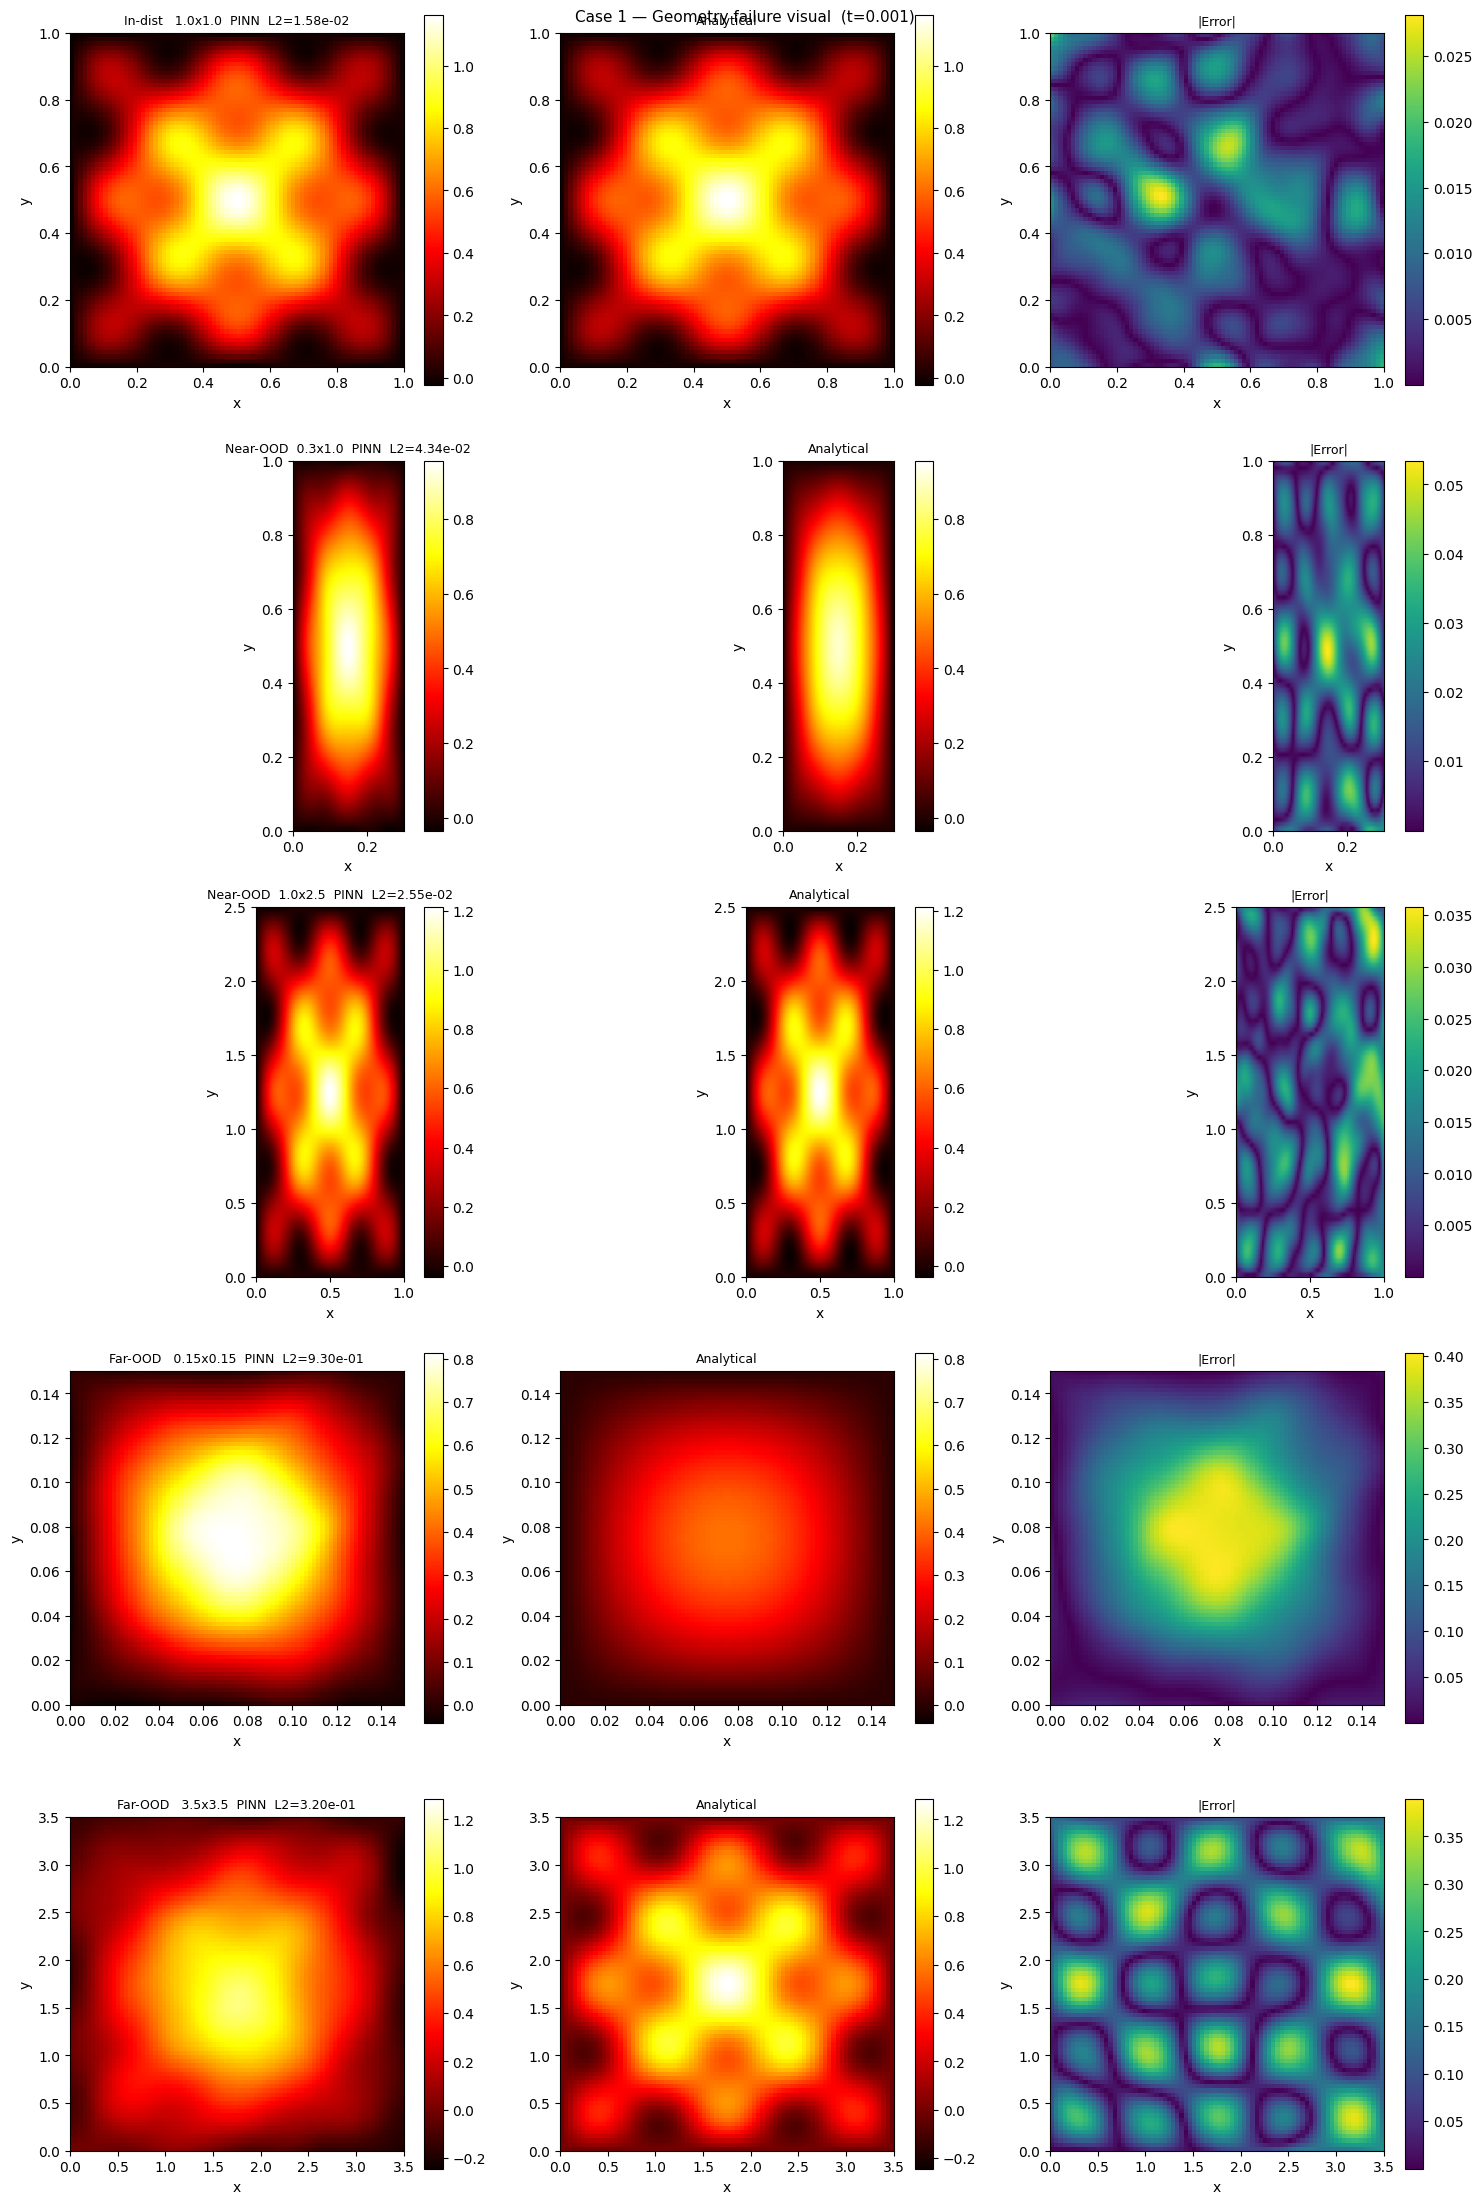

Saved case1_geometry_visual.png


In [8]:
CASES = [
    ('In-dist   1.0x1.0',   1.0,  1.0),
    ('Near-OOD  0.3x1.0',   0.3,  1.0),
    ('Near-OOD  1.0x2.5',   1.0,  2.5),
    ('Far-OOD   0.15x0.15', 0.15, 0.15),
    ('Far-OOD   3.5x3.5',   3.5,  3.5),
]

fig, axes = plt.subplots(len(CASES), 3, figsize=(15, 4.5*len(CASES)))
print(f'{"Case":>24} | {"lx_n":>6} | {"L2":>9}')
for row, (name, Lx, Ly) in enumerate(CASES):
    l2, T_pred, T_true = eval_l2(Lx, Ly, 0.001)
    lx_n = (Lx-1.25)/0.75; ly_n = (Ly-1.25)/0.75
    print(f'{name:>24} | {lx_n:>6.2f} | {l2:>9.2e}')
    vmin = min(T_pred.min(), T_true.min()); vmax = max(T_pred.max(), T_true.max())
    kw = dict(origin='lower', extent=[0,Lx,0,Ly], cmap='hot', vmin=vmin, vmax=vmax)
    im = axes[row,0].imshow(T_pred, **kw)
    axes[row,0].set_title(f'{name}  PINN  L2={l2:.2e}', fontsize=9); plt.colorbar(im, ax=axes[row,0])
    im = axes[row,1].imshow(T_true, **kw)
    axes[row,1].set_title('Analytical', fontsize=9); plt.colorbar(im, ax=axes[row,1])
    im = axes[row,2].imshow(np.abs(T_pred-T_true), origin='lower', extent=[0,Lx,0,Ly], cmap='viridis')
    axes[row,2].set_title('|Error|', fontsize=9); plt.colorbar(im, ax=axes[row,2])
    for ax in axes[row]: ax.set_xlabel('x'); ax.set_ylabel('y')
fig.suptitle('Case 1 — Geometry failure visual  (t=0.001)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/case1_geometry_visual.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved case1_geometry_visual.png')

## Case 2 — Temporal Extrapolation
Training window: `t ∈ [0, T_MAX=0.01]`. Beyond T_MAX the model was never trained
and has no physics constraint forcing continued decay.

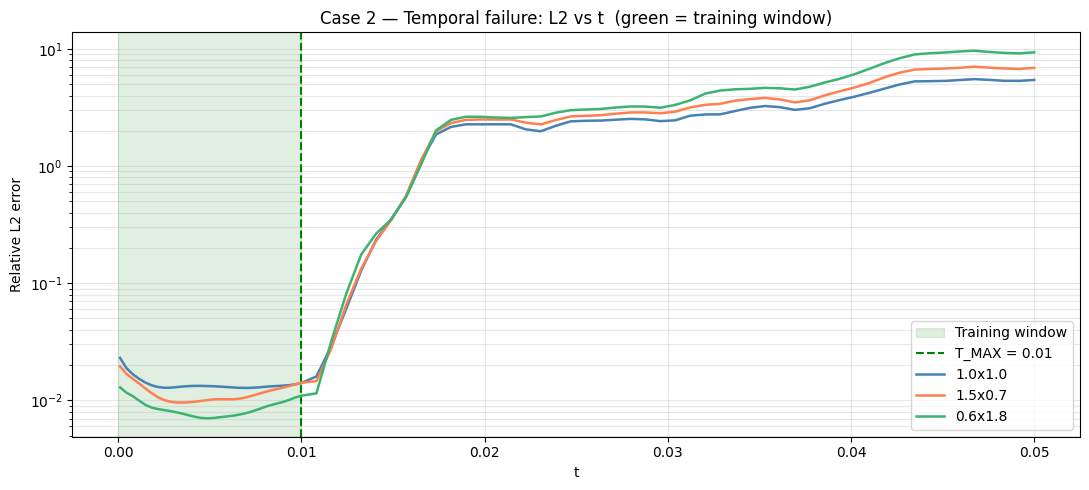

Saved case2_time_sweep.png


In [9]:
t_all = np.concatenate([np.linspace(0.0001, T_MAX, 30), np.linspace(T_MAX, 5*T_MAX, 50)])
TIME_GEOMS = [('1.0x1.0',1.0,1.0), ('1.5x0.7',1.5,0.7), ('0.6x1.8',0.6,1.8)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(0, T_MAX, alpha=0.12, color='green', label='Training window')
ax.axvline(T_MAX, color='green', ls='--', lw=1.5, label=f'T_MAX = {T_MAX}')
for (name, Lx, Ly), color in zip(TIME_GEOMS, ['steelblue','coral','mediumseagreen']):
    errs = [eval_l2(Lx, Ly, t)[0] for t in t_all]
    ax.semilogy(t_all, errs, lw=1.8, label=name, color=color)
ax.set_xlabel('t'); ax.set_ylabel('Relative L2 error')
ax.set_title('Case 2 — Temporal failure: L2 vs t  (green = training window)')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/case2_time_sweep.png', dpi=150); plt.show()
print('Saved case2_time_sweep.png')

       t |    t_n |        L2 | status
  0.0050 |   0.00 |  1.32e-02 | in-dist
  0.0100 |   1.00 |  1.41e-02 | in-dist
  0.0200 |   3.00 |  2.27e+00 | OOD (t_n=3.0)
  0.0400 |   7.00 |  3.85e+00 | OOD (t_n=7.0)


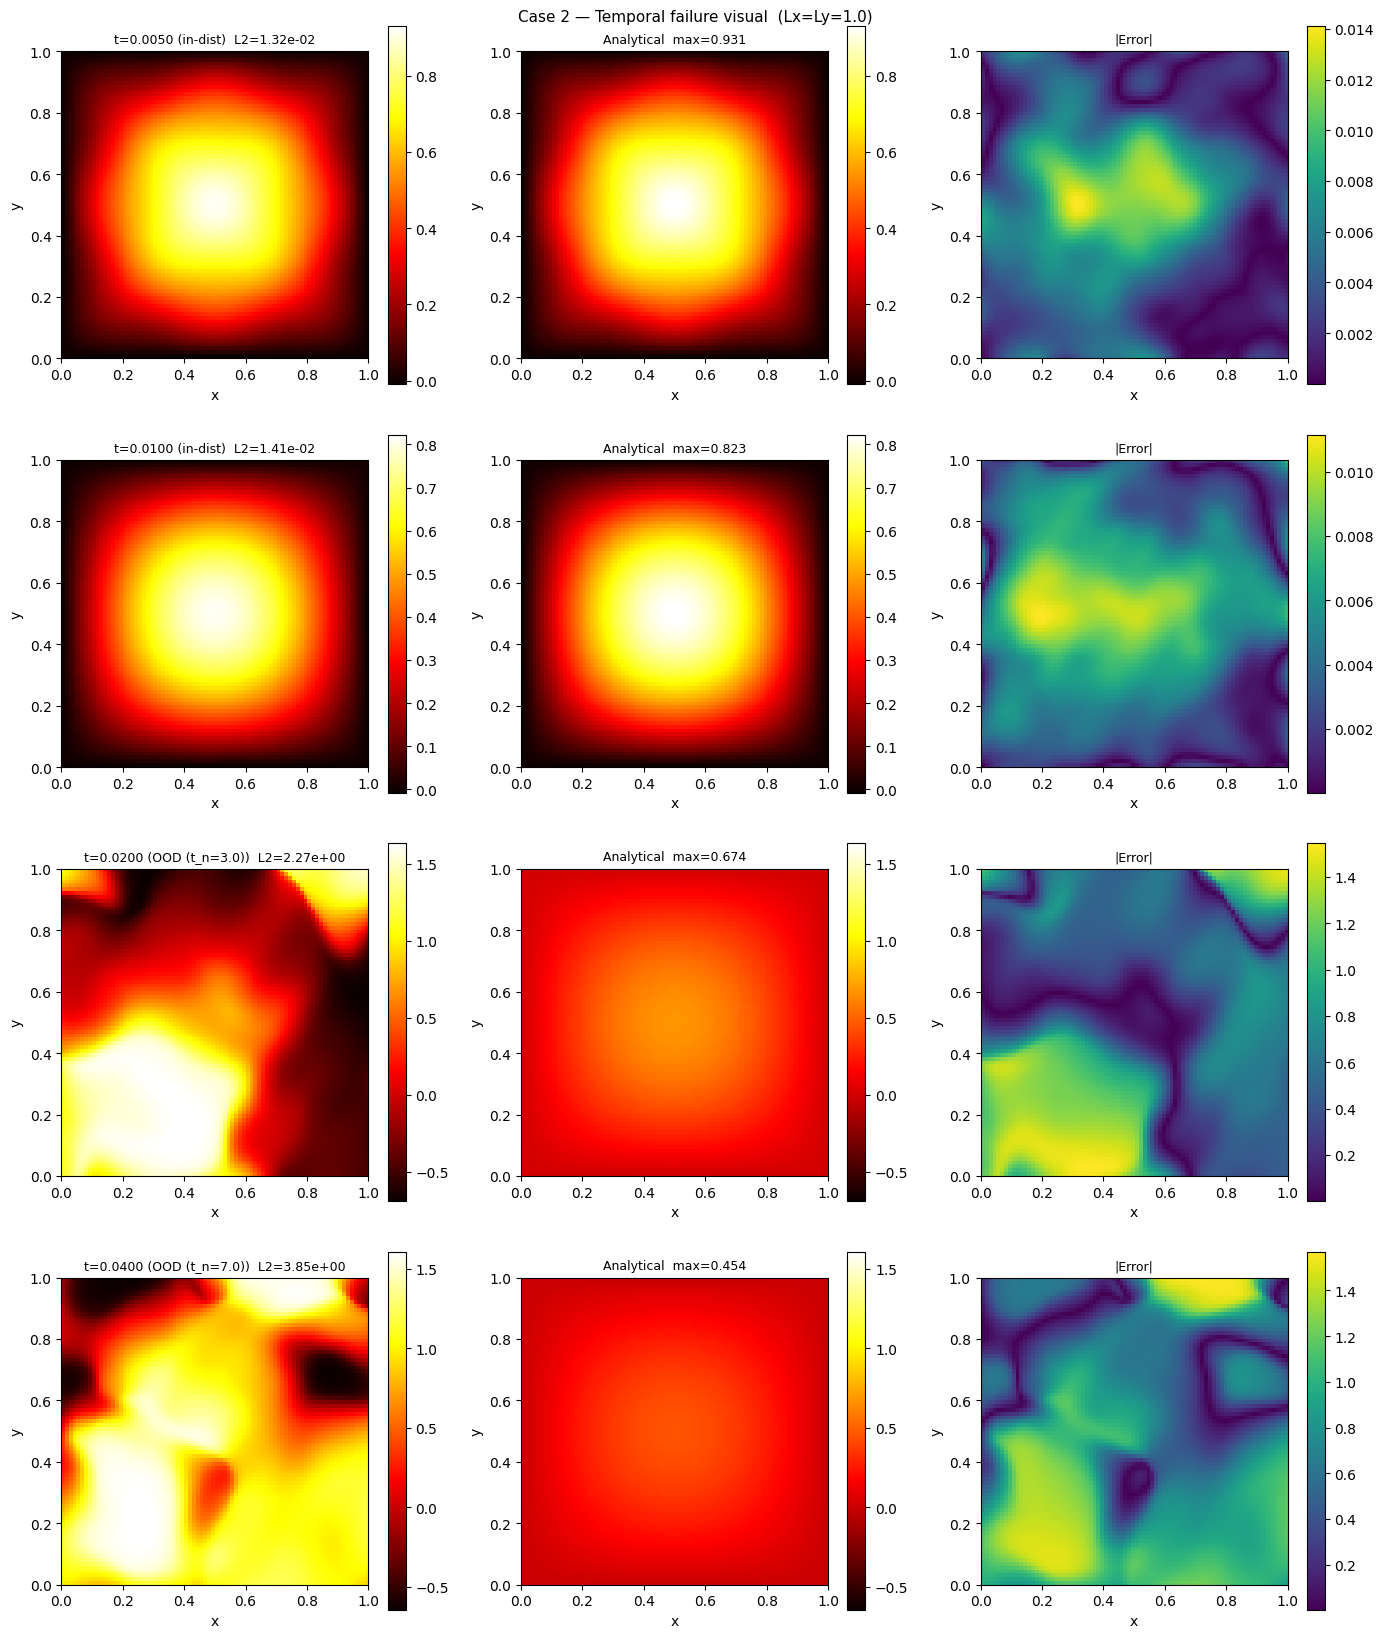

Saved case2_time_visual.png


In [10]:
T_SNAPS = [0.5*T_MAX, T_MAX, 2*T_MAX, 4*T_MAX]
Lx_t = Ly_t = 1.0

fig, axes = plt.subplots(len(T_SNAPS), 3, figsize=(14, 4.2*len(T_SNAPS)))
print(f'{"t":>8} | {"t_n":>6} | {"L2":>9} | status')
for row, t_val in enumerate(T_SNAPS):
    l2, T_pred, T_true = eval_l2(Lx_t, Ly_t, t_val)
    t_n = 2*t_val/T_MAX - 1
    status = 'in-dist' if t_val <= T_MAX else f'OOD (t_n={t_n:.1f})'
    print(f'{t_val:>8.4f} | {t_n:>6.2f} | {l2:>9.2e} | {status}')
    vmin = min(T_pred.min(), T_true.min()); vmax = max(T_pred.max(), T_true.max())
    kw = dict(origin='lower', extent=[0,Lx_t,0,Ly_t], cmap='hot', vmin=vmin, vmax=vmax)
    im = axes[row,0].imshow(T_pred, **kw)
    axes[row,0].set_title(f't={t_val:.4f} ({status})  L2={l2:.2e}', fontsize=9); plt.colorbar(im, ax=axes[row,0])
    im = axes[row,1].imshow(T_true, **kw)
    axes[row,1].set_title(f'Analytical  max={T_true.max():.3f}', fontsize=9); plt.colorbar(im, ax=axes[row,1])
    im = axes[row,2].imshow(np.abs(T_pred-T_true), origin='lower', extent=[0,Lx_t,0,Ly_t], cmap='viridis')
    axes[row,2].set_title('|Error|', fontsize=9); plt.colorbar(im, ax=axes[row,2])
    for ax in axes[row]: ax.set_xlabel('x'); ax.set_ylabel('y')
fig.suptitle('Case 2 — Temporal failure visual  (Lx=Ly=1.0)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/case2_time_visual.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved case2_time_visual.png')

## Case 3 — Thermal Diffusivity Mismatch
α is not a model input — it is hardcoded at training time (α=1.0).
The model always outputs the α=1.0 solution. Here we measure how wrong
it is when the true physics has a different α.

> **Fix direction:** the same transfer learning approach used for geometry (Fix 1 in the
> fixes notebook) could be applied here — add α as a 6th network input and fine-tune
> on a range of α values. Not implemented here but structurally identical.

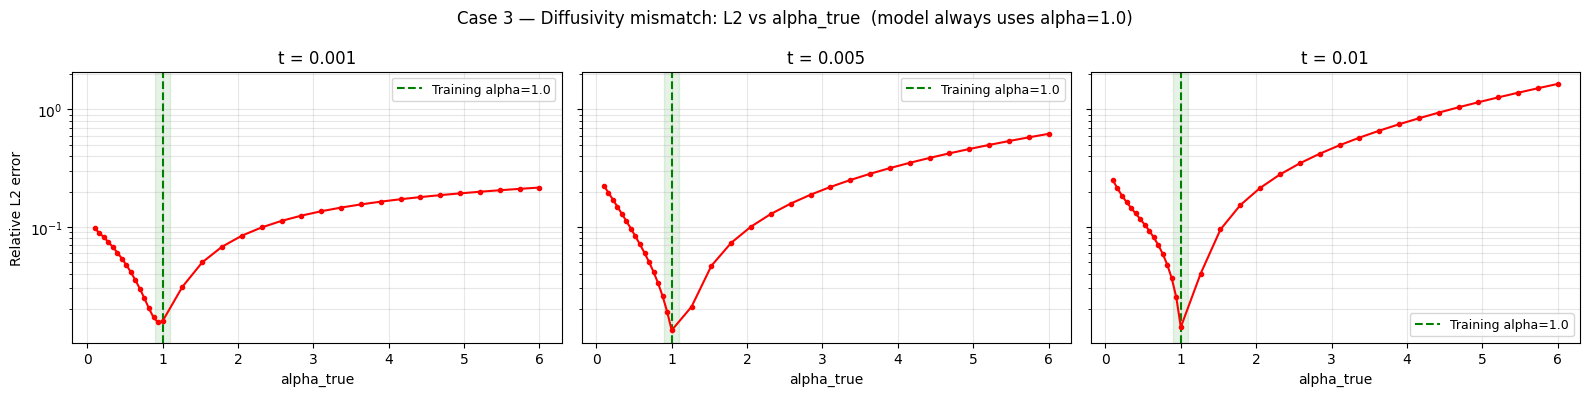

 alpha |        L2 | note
  0.25 |  1.47e-01 | over-predicts
  0.50 |  8.51e-02 | over-predicts
  1.00 |  1.29e-02 | in-dist
  2.00 |  7.84e-02 | under-predicts
  4.00 |  2.01e-01 | under-predicts


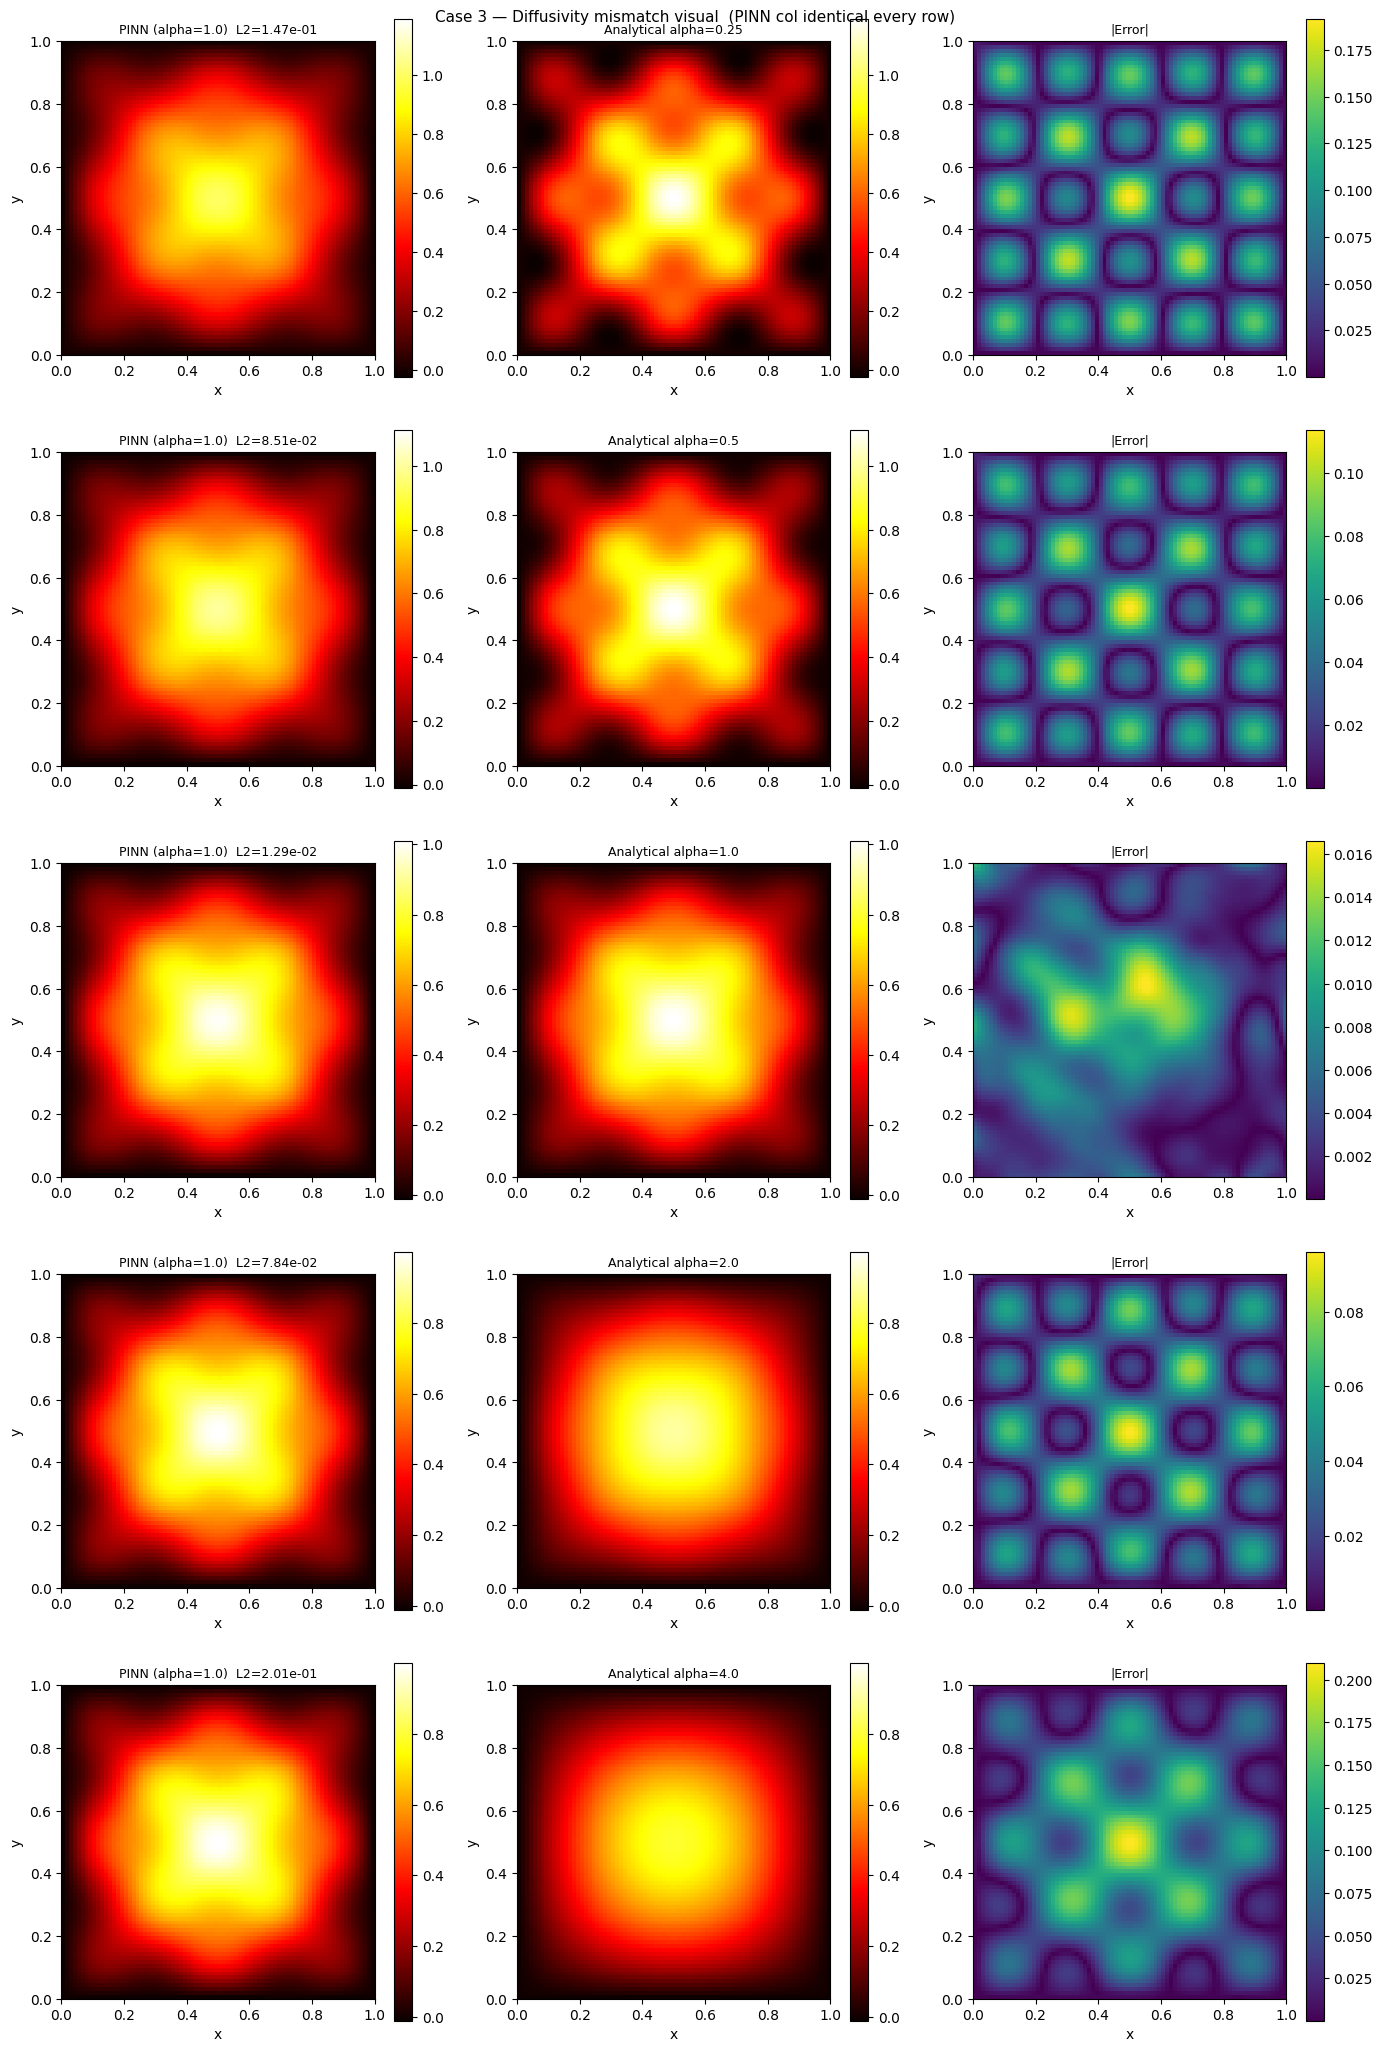

Saved case3_alpha_sweep.png and case3_alpha_visual.png


In [11]:
alpha_vals = np.concatenate([np.linspace(0.1, 1.0, 15, endpoint=False), np.linspace(1.0, 6.0, 20)])
Lx_a = Ly_a = 1.0

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, t_val in zip(axes, [0.001, 0.005, 0.010]):
    errs = [eval_l2(Lx_a, Ly_a, t_val, alpha_true=a)[0] for a in alpha_vals]
    ax.axvline(1.0, color='green', ls='--', lw=1.5, label='Training alpha=1.0')
    ax.axvspan(0.9, 1.1, alpha=0.1, color='green')
    ax.semilogy(alpha_vals, errs, 'r-o', ms=3, lw=1.5)
    ax.set_xlabel('alpha_true'); ax.set_title(f't = {t_val}')
    ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('Relative L2 error')
fig.suptitle('Case 3 — Diffusivity mismatch: L2 vs alpha_true  (model always uses alpha=1.0)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/case3_alpha_sweep.png', dpi=150); plt.show()

ALPHA_VIS = [0.25, 0.5, 1.0, 2.0, 4.0]
_, T_pinn, _ = eval_l2(1.0, 1.0, 0.003, alpha_true=1.0)
fig, axes = plt.subplots(len(ALPHA_VIS), 3, figsize=(14, 4.2*len(ALPHA_VIS)))
print(f'{"alpha":>6} | {"L2":>9} | note')
for row, a in enumerate(ALPHA_VIS):
    l2, _, T_true = eval_l2(1.0, 1.0, 0.003, alpha_true=a)
    note = 'in-dist' if a==1.0 else ('over-predicts' if a<1.0 else 'under-predicts')
    print(f'{a:>6.2f} | {l2:>9.2e} | {note}')
    vmin = min(T_pinn.min(), T_true.min()); vmax = max(T_pinn.max(), T_true.max())
    kw = dict(origin='lower', extent=[0,1,0,1], cmap='hot', vmin=vmin, vmax=vmax)
    im = axes[row,0].imshow(T_pinn, **kw)
    axes[row,0].set_title(f'PINN (alpha=1.0)  L2={l2:.2e}', fontsize=9); plt.colorbar(im, ax=axes[row,0])
    im = axes[row,1].imshow(T_true, **kw)
    axes[row,1].set_title(f'Analytical alpha={a}', fontsize=9); plt.colorbar(im, ax=axes[row,1])
    im = axes[row,2].imshow(np.abs(T_pinn-T_true), origin='lower', extent=[0,1,0,1], cmap='viridis')
    axes[row,2].set_title('|Error|', fontsize=9); plt.colorbar(im, ax=axes[row,2])
    for ax in axes[row]: ax.set_xlabel('x'); ax.set_ylabel('y')
fig.suptitle('Case 3 — Diffusivity mismatch visual  (PINN col identical every row)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/case3_alpha_visual.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved case3_alpha_sweep.png and case3_alpha_visual.png')

In [12]:
# Diagnostic helper — computes mean |PDE residual| at n random interior points
# residual = |dT/dt - alpha*(d2T/dx2 + d2T/dy2)|
# alpha parameter lets us check residual for ANY diffusivity, not just the trained one
def pde_res_mag(Lx, Ly, t_val, alpha=ALPHA, n=300):
    pts = torch.cat([
        torch.rand(n,1)*Lx, torch.rand(n,1)*Ly,
        torch.full((n,1), t_val),
        torch.full((n,1), Lx), torch.full((n,1), Ly)
    ], dim=1).to(DEVICE)
    pts.requires_grad_(True)
    T  = model(pts)
    g  = torch.autograd.grad(T.sum(), pts, create_graph=True)[0]
    Tx, Ty, Tt = g[:,0:1], g[:,1:2], g[:,2:3]
    Txx = torch.autograd.grad(Tx.sum(), pts, retain_graph=True)[0][:,0:1]
    Tyy = torch.autograd.grad(Ty.sum(), pts, retain_graph=True)[0][:,1:2]
    res = (Tt - alpha*(Txx + Tyy)).abs().mean().item()
    return res

# Sanity check: in-dist case should have low PDE residual
print(f'In-dist PDE residual  Lx=Ly=1 t=0.001: {pde_res_mag(1.0,1.0,0.001):.3e}')

In-dist PDE residual  Lx=Ly=1 t=0.001: 1.789e+00


Case 1 diagnostic done


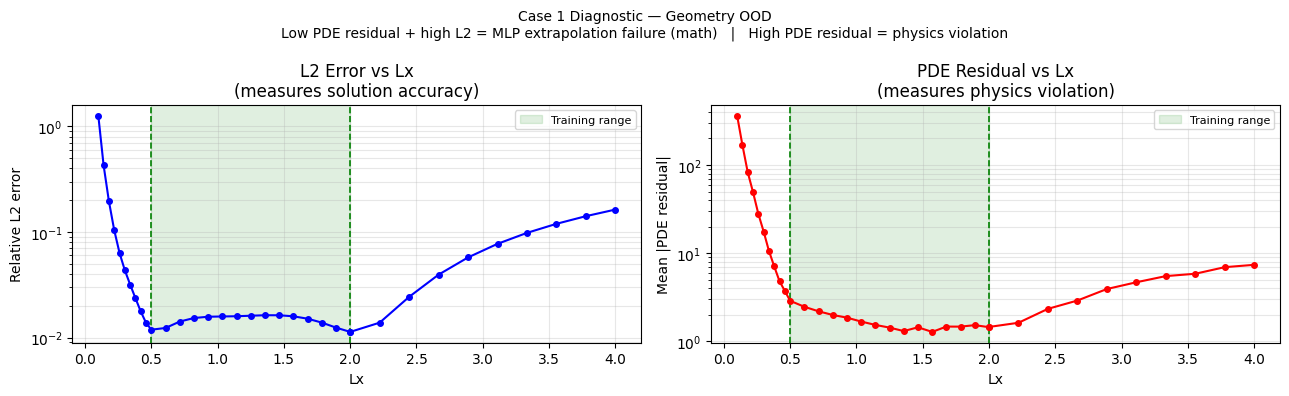

Saved case1_diagnostic.png


In [13]:
# Case 1 diagnostic: does the model still satisfy the PDE for OOD geometries?
# If PDE residual is low but L2 is high → mathematical MLP failure
# If PDE residual is high → physical violation
lx_diag = np.concatenate([
    np.linspace(0.1, 0.5, 10, endpoint=False),
    np.linspace(0.5, 2.0, 15),
    np.linspace(2.0, 4.0, 10)
])
Ly_d = 1.0; t_d = 0.001

l2_d1  = [eval_l2(Lx, Ly_d, t_d)[0]        for Lx in lx_diag]
pde_d1 = [pde_res_mag(Lx, Ly_d, t_d)        for Lx in lx_diag]
print('Case 1 diagnostic done')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax in axes:
    ax.axvspan(0.5, 2.0, alpha=0.12, color='green', label='Training range')
    ax.axvline(0.5, color='green', ls='--', lw=1.2)
    ax.axvline(2.0, color='green', ls='--', lw=1.2)
    ax.set_xlabel('Lx'); ax.grid(True, which='both', alpha=0.3)

axes[0].semilogy(lx_diag, l2_d1, 'b-o', ms=4, lw=1.5)
axes[0].set_ylabel('Relative L2 error')
axes[0].set_title('L2 Error vs Lx\n(measures solution accuracy)')
axes[0].legend(fontsize=8)

axes[1].semilogy(lx_diag, pde_d1, 'r-o', ms=4, lw=1.5)
axes[1].set_ylabel('Mean |PDE residual|')
axes[1].set_title('PDE Residual vs Lx\n(measures physics violation)')
axes[1].legend(fontsize=8)

fig.suptitle(
    'Case 1 Diagnostic — Geometry OOD\n'
    'Low PDE residual + high L2 = MLP extrapolation failure (math)   |   '
    'High PDE residual = physics violation',
    fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/case1_diagnostic.png', dpi=150); plt.show()
print('Saved case1_diagnostic.png')

Case 2 diagnostic done


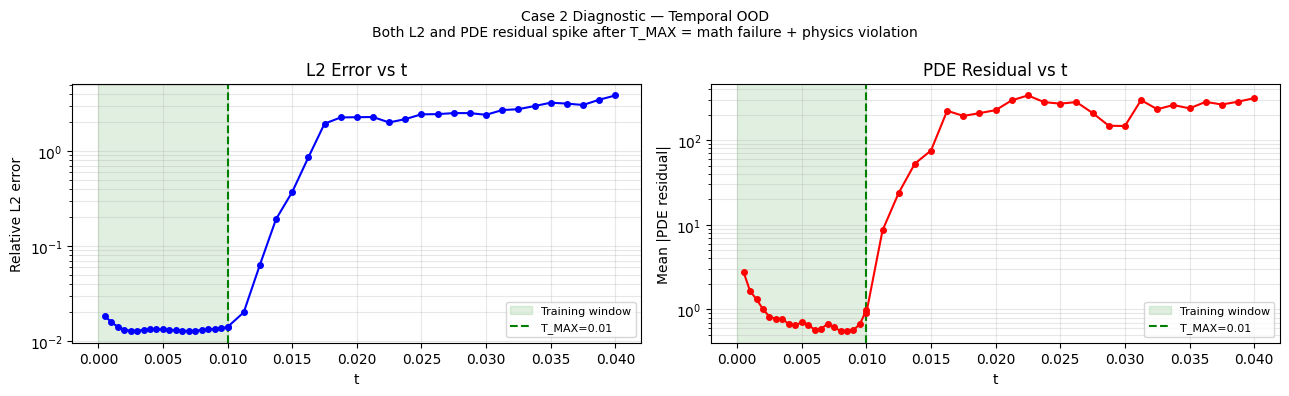

Saved case2_diagnostic.png


In [14]:
# Case 2 diagnostic: where exactly does the model stop satisfying the PDE in time?
# Expect: PDE residual stays low inside training window, spikes after T_MAX
t_diag = np.concatenate([
    np.linspace(0.0005, T_MAX,     20),
    np.linspace(T_MAX,  4*T_MAX,   25)
])
Lx_d = Ly_d = 1.0

l2_d2  = [eval_l2(Lx_d, Ly_d, t)[0]   for t in t_diag]
pde_d2 = [pde_res_mag(Lx_d, Ly_d, t)   for t in t_diag]
print('Case 2 diagnostic done')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax in axes:
    ax.axvspan(0, T_MAX, alpha=0.12, color='green', label='Training window')
    ax.axvline(T_MAX, color='green', ls='--', lw=1.5, label=f'T_MAX={T_MAX}')
    ax.set_xlabel('t'); ax.grid(True, which='both', alpha=0.3)

axes[0].semilogy(t_diag, l2_d2, 'b-o', ms=4, lw=1.5)
axes[0].set_ylabel('Relative L2 error')
axes[0].set_title('L2 Error vs t')
axes[0].legend(fontsize=8)

axes[1].semilogy(t_diag, pde_d2, 'r-o', ms=4, lw=1.5)
axes[1].set_ylabel('Mean |PDE residual|')
axes[1].set_title('PDE Residual vs t')
axes[1].legend(fontsize=8)

fig.suptitle(
    'Case 2 Diagnostic — Temporal OOD\n'
    'Both L2 and PDE residual spike after T_MAX = math failure + physics violation',
    fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/case2_diagnostic.png', dpi=150); plt.show()
print('Saved case2_diagnostic.png')

Case 3 diagnostic done


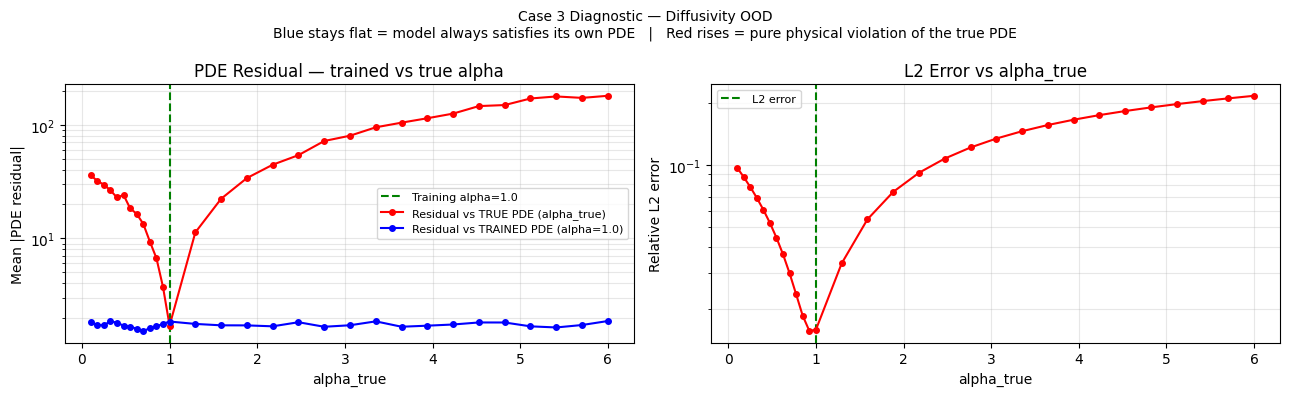

Saved case3_diagnostic.png


In [15]:
# Case 3 diagnostic: model always satisfies its OWN PDE (alpha=1.0)
# but violates the TRUE PDE when alpha_true != 1.0
# Two residual lines:
#   red  — residual of model output vs TRUE PDE (alpha_true)  → rises away from 1.0
#   blue — residual of model output vs TRAINED PDE (alpha=1.0) → stays flat/low
alpha_diag = np.concatenate([
    np.linspace(0.1, 1.0, 12, endpoint=False),
    np.linspace(1.0, 6.0, 18)
])
Lx_d = Ly_d = 1.0; t_d = 0.001

res_trained = [pde_res_mag(Lx_d, Ly_d, t_d, alpha=1.0)       for _ in alpha_diag]  # always alpha=1
res_true    = [pde_res_mag(Lx_d, Ly_d, t_d, alpha=float(a))  for a in alpha_diag]  # alpha_true
l2_d3       = [eval_l2(Lx_d, Ly_d, t_d, alpha_true=float(a))[0] for a in alpha_diag]
print('Case 3 diagnostic done')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax in axes:
    ax.axvline(1.0, color='green', ls='--', lw=1.5, label='Training alpha=1.0')
    ax.set_xlabel('alpha_true'); ax.grid(True, which='both', alpha=0.3)

axes[0].semilogy(alpha_diag, res_true,    'r-o', ms=4, lw=1.5, label='Residual vs TRUE PDE (alpha_true)')
axes[0].semilogy(alpha_diag, res_trained, 'b-o', ms=4, lw=1.5, label='Residual vs TRAINED PDE (alpha=1.0)')
axes[0].set_ylabel('Mean |PDE residual|')
axes[0].set_title('PDE Residual — trained vs true alpha')
axes[0].legend(fontsize=8)

axes[1].semilogy(alpha_diag, l2_d3, 'r-o', ms=4, lw=1.5)
axes[1].set_ylabel('Relative L2 error')
axes[1].set_title('L2 Error vs alpha_true')
axes[1].legend(['L2 error'], fontsize=8)

fig.suptitle(
    'Case 3 Diagnostic — Diffusivity OOD\n'
    'Blue stays flat = model always satisfies its own PDE   |   '
    'Red rises = pure physical violation of the true PDE',
    fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/case3_diagnostic.png', dpi=150); plt.show()
print('Saved case3_diagnostic.png')

## Diagnostic Summary

| Case | PDE Residual OOD | L2 Error OOD | Failure Type |
|---|---|---|---|
| Geometry | Low-moderate | High | **Mathematical** — MLP extrapolation (tanh saturation) |
| Temporal  | High (spikes at T_MAX) | High | **Both** — MLP + physics violation (∂T/∂t ≠ α∇²T) |
| Diffusivity | Low for α=1.0, high for α_true | Moderate | **Physical** — model solves the wrong PDE |